In [4]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
import torch
import math

In [2]:
context_len = 500
d = 300 # = embeddings dimension

T, C = context_len, d 

m = np.arange(0, T, 1)
m = torch.from_numpy(m) # (T)

i = torch.arange(d // 2)
thetas = 10_000 ** (-2 * i / d) # (D/2)
angles = torch.outer(m, thetas) # (T, D/2)

rot_matr_1 = torch.ones(T, d)
rot_matr_2 = torch.ones(T, d)

for i in range(T):
    for j in range(d // 2):
        rot_matr_1[i, j*2] = torch.cos(angles[i, j])
        rot_matr_1[i, j*2+1] = torch.cos(angles[i, j])

        rot_matr_2[i, j*2] = torch.sin(angles[i, j])
        rot_matr_2[i, j*2+1] = torch.sin(angles[i, j])

x = torch.ones(T, d)
x_shaked = torch.stack([-x[:, 1::2], x[:, 0::2]], dim=-1).flatten(start_dim=1)

rope_x = torch.mul(x, rot_matr_1) + torch.mul(x_shaked, rot_matr_2) # (T, C)




rope.gif sauvegardé !


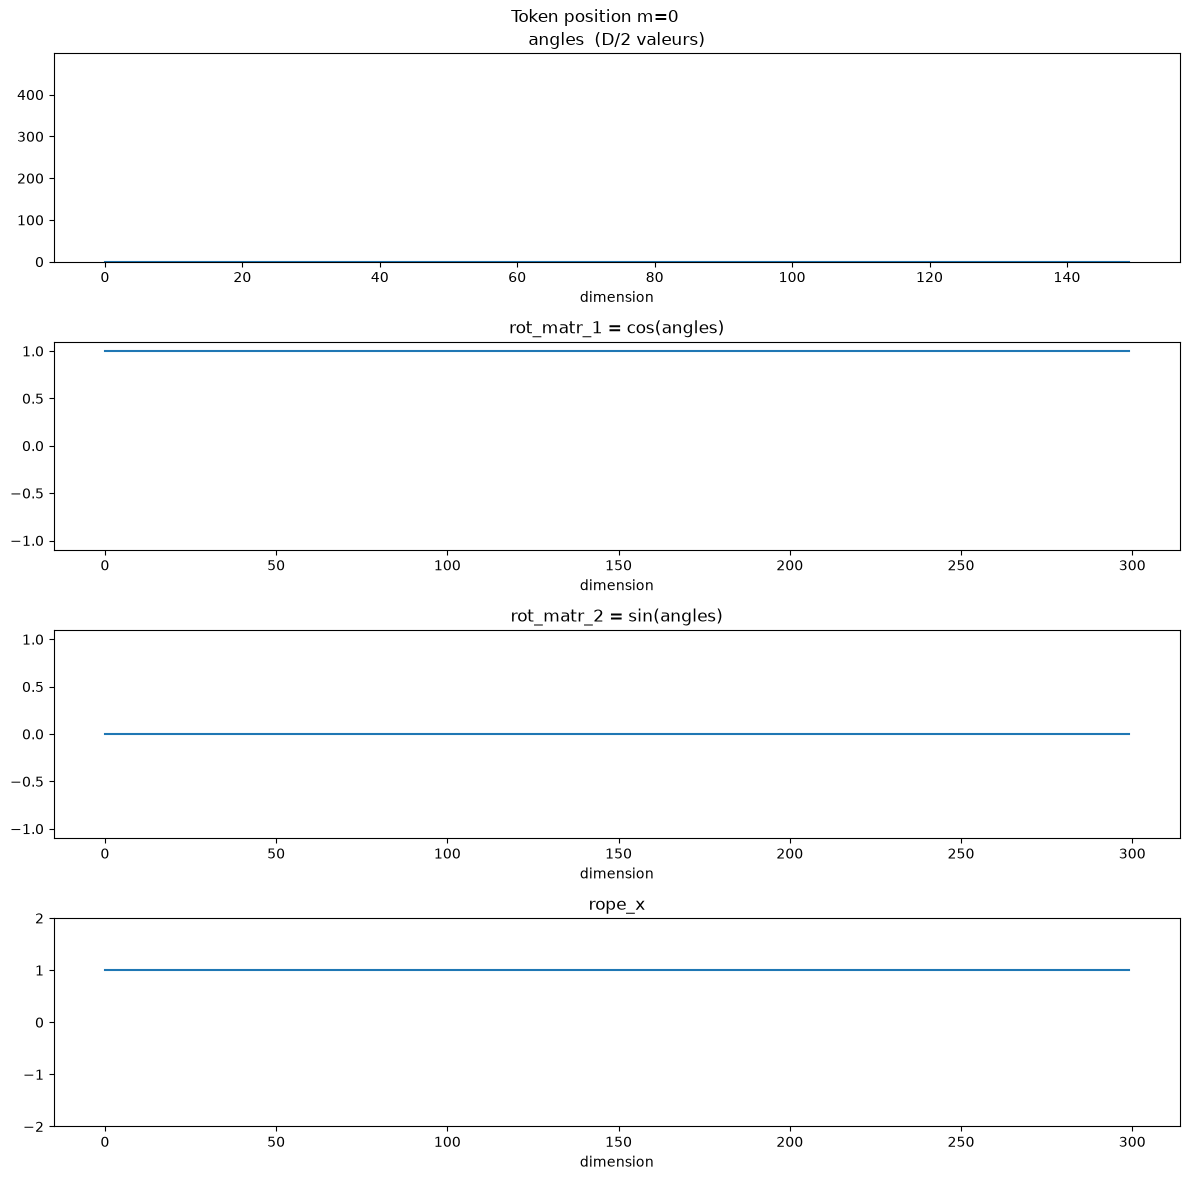

In [10]:
# AI generated vvvvvvv


fig, axes = plt.subplots(4, 1, figsize=(12, 12))
fig.suptitle('Token position m=0')

lines = [
    axes[0].plot(angles[0].numpy())[0],
    axes[1].plot(rot_matr_1[0].numpy())[0],
    axes[2].plot(rot_matr_2[0].numpy())[0],
    axes[3].plot(rope_x[0].numpy())[0],
]

titles = ['angles  (D/2 valeurs)', 'rot_matr_1 = cos(angles)', 'rot_matr_2 = sin(angles)', 'rope_x']
ylims  = [(0, angles.max().item()), (-1.1, 1.1), (-1.1, 1.1), (-2, 2)]

for ax, t, yl in zip(axes, titles, ylims):
    ax.set_title(t)
    ax.set_ylim(*yl)
    ax.set_xlabel('dimension')

fig.tight_layout()

data = [angles, rot_matr_1, rot_matr_2, rope_x]

def update(frame):
    for line, arr in zip(lines, data):
        line.set_ydata(arr[frame].numpy())
    fig.suptitle(f'Token position m={frame}')
    return lines

ani = animation.FuncAnimation(fig, update, frames=T, interval=50, blit=False)
ani.save('rope.gif', writer='pillow', fps=20)

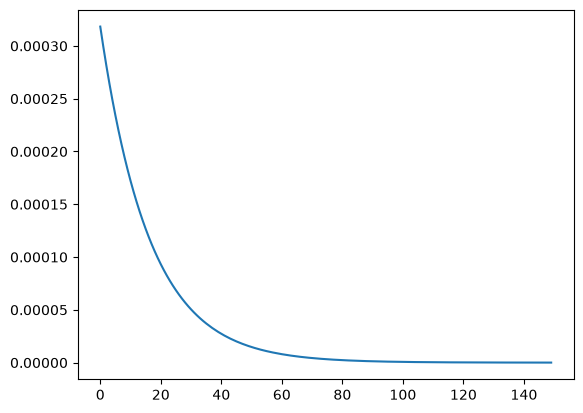

In [8]:
wave_len = thetas / (2*math.pi)
ratio = wave_len / context_len
plt.plot(ratio.detach().cpu().numpy())
plt.show()